In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

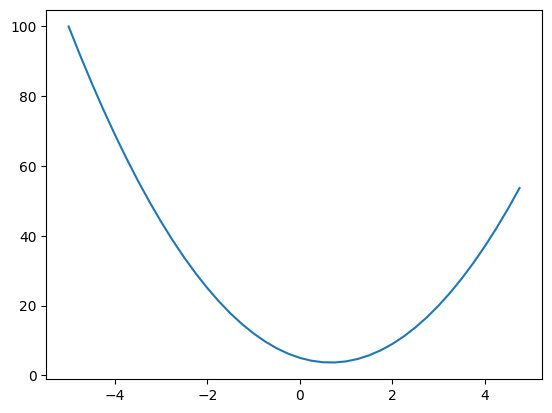

In [8]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [16]:
h= 0.000000001
x = 2/3
(f(x + h) - f(x))/h

0.0

In [18]:
# more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [19]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [3]:
import math
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float values for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += (other.data) * out.grad
            other.grad += (self.data) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += (other.data) * out.grad
            other.grad += (self.data) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self):
        return self  * -1

    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
        
    
    def backward(self):

        topo = []
        visited = set()
        def build_topo (v):
            if v not in visited: 
                visited.add(v)
                for child in v._prev: 
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        topo

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [293]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [ ]:
a/b
a / (1/b)
a / (b**-1)

In [152]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [108]:
d._op

'+'

In [4]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad.%4f }" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

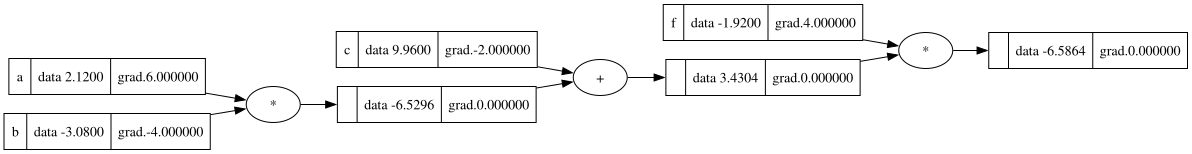

In [141]:
draw_dot(L)

In [140]:
a.data+=0.01 * a.grad
b.data+=0.01 * b.grad
c.data+=0.01 * c.grad
f.data+=0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-6.586368000000001


In [136]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [ ]:
dL / de = -2.0
e = a * b
de / da? b
dL / da = (dL / de) * (de / da)

In [132]:
c.grad = -2.0 
e.grad = -2.0

In [ ]:
dd / dc = 1.0
dd / de = 1.0
d = c + e

WANT:
dL / dc = (dL / dd) * (dd / dc)

KNOW:
dL / dd
dd / dc


In [111]:
L.grad = 1.0 

In [114]:
L = d * f 
dL/dd =? f

(f(x+h) + f(x))/h

((d+h)*f - d*f)/h
(d*f + h*f - d*f)/h
(h*f)/h
f

SyntaxError: cannot assign to expression (1885890814.py, line 2)

In [120]:
f.grad = 4.0
d.grad = -2.0 

In [199]:
def lol():
    
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data+=h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


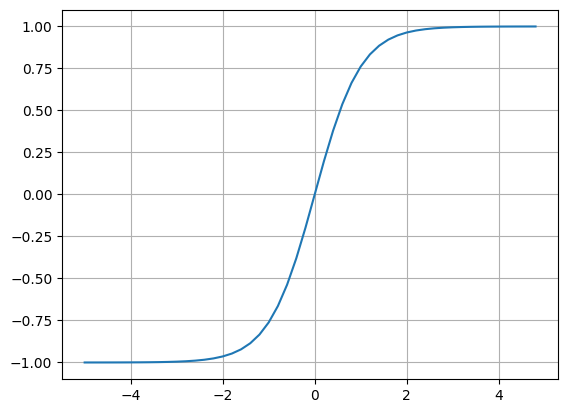

In [200]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

## Backpropagtion through a simple neural network

In [349]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label ='o'
o.backward()

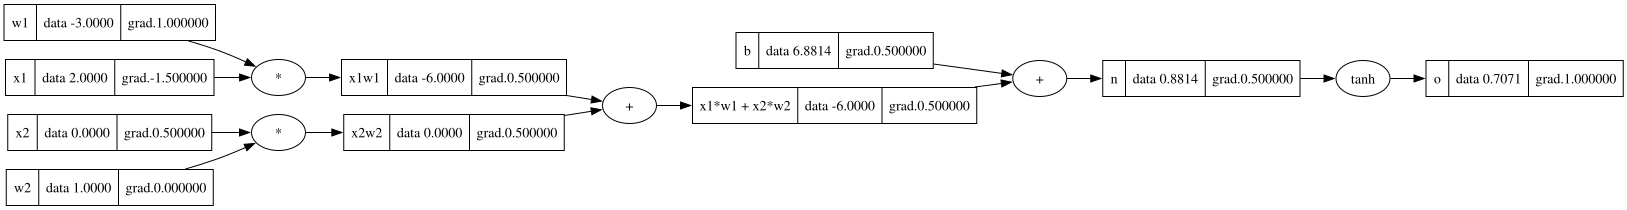

In [350]:
draw_dot(o)

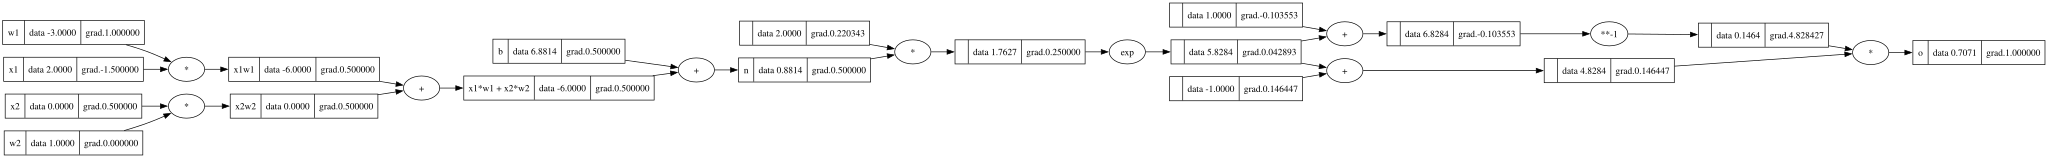

In [348]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# --------
e = (2*n).exp()
o = (e-1)/(e+1)
# --------
o.label ='o'
o.backward()
draw_dot(o)

## Pytorch implementation for the same neural network

In [352]:
import torch

x1 = torch.Tensor([2.0]).double()  ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()  ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()  ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195342]).double() ; b.requires_grad = True
n = x1*w1  + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [316]:
o.backward

In [251]:
topo = []
visited = set()
def build_topo (v):
    if v not in visited: 
        visited.add(v)
        for child in v._prev: 
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [221]:
o._backward()

In [222]:
n._backward()

In [223]:
x1w1x2w2._backward()

In [224]:
x2w2._backward()
x1w1._backward()

In [174]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [172]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [170]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [168]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [164]:
n.grad = 0.5

In [160]:
o.grad = 1.0 

In [163]:
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(n)
# do/dn = 1 - o**2

## Accumulating gradients example 

Fixing the bug that lets accumlate the gradients when a node is being used in multiple operations

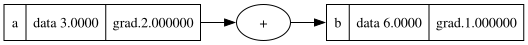

In [252]:
a = Value(3.0,label='a')
b = a + a; b.label ='b'
b.backward()
draw_dot(b)

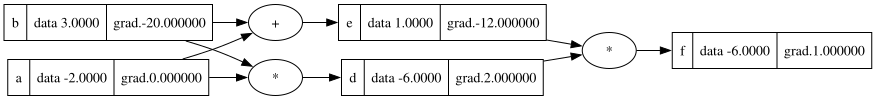

In [253]:
a = Value(-2.0,label='a')
b = Value(3.0,label='b')
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()

draw_dot(f)

In [52]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0]

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [53]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.4351827953283134)

In [17]:
n.parameters()

[Value(data=0.2443646360360865),
 Value(data=-0.49934842186546624),
 Value(data=-0.24945731493037449),
 Value(data=0.5529672465189674),
 Value(data=0.8955976318142067),
 Value(data=0.5854647787153868),
 Value(data=-0.8032765883500694),
 Value(data=-0.633867454624043),
 Value(data=0.6713837798577695),
 Value(data=0.4541700885488573),
 Value(data=0.9386343176895184),
 Value(data=-0.7388327313791068),
 Value(data=-0.7410329303855681),
 Value(data=-0.18162019089623094),
 Value(data=0.40248062244414484),
 Value(data=0.3104734341738289),
 Value(data=-0.2966262030470792),
 Value(data=0.20297082629488772),
 Value(data=-0.5160080467143444),
 Value(data=0.3229834835332501),
 Value(data=-0.3386790637410384),
 Value(data=0.3499543832803025),
 Value(data=0.903714868074105),
 Value(data=-0.0635245433208469),
 Value(data=0.006436512778606129),
 Value(data=-0.39508698015620625),
 Value(data=-0.8080244209941627),
 Value(data=0.9892875836543633),
 Value(data=-0.9447794219283656),
 Value(data=-0.19234104

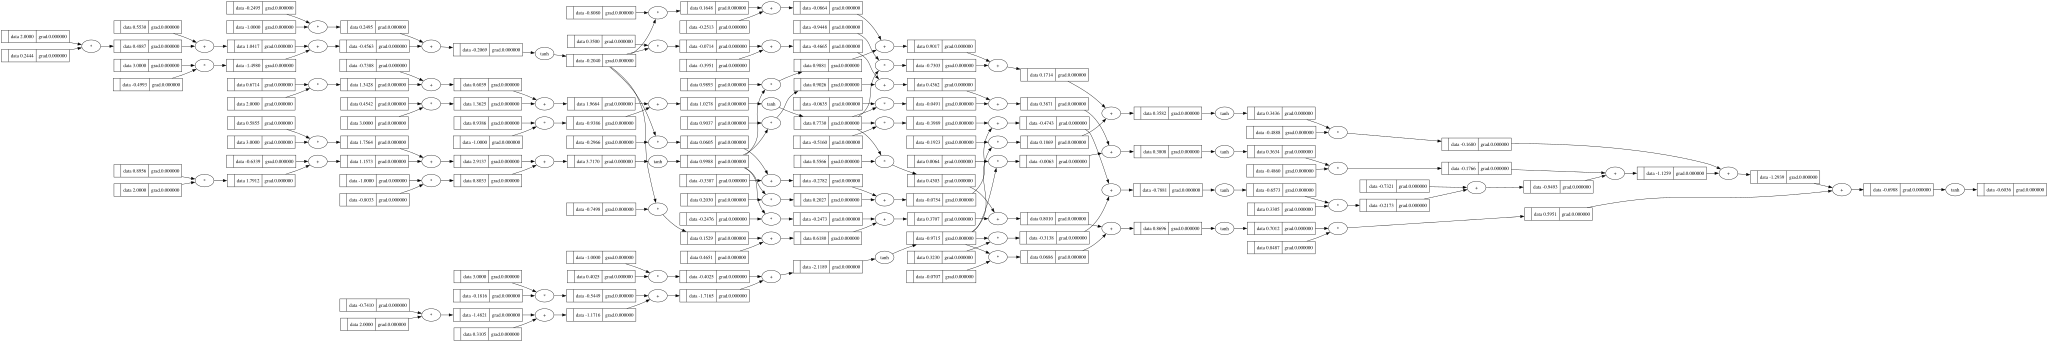

In [18]:
draw_dot(n(x))

In [54]:
xs = [
[2.0, 3.0, -1.0],
[3.0, -1.0, 0.5],
[0.5, 1.0, 1.0],
[1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [59]:

for k in range(20):
    
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)], Value(0.0))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)
    

0 0.01731648238689757
1 0.016987950791732296
2 0.016670816440228838
3 0.016364505806609895
4 0.016068483024661018
5 0.015782246851720035
6 0.015505327921558232
7 0.01523728625458378
8 0.01497770899768137
9 0.014726208369355582
10 0.014482419788747557
11 0.014246000169615278
12 0.014016626362556845
13 0.0137939937306665
14 0.013577814845480334
15 0.013367818291527066
16 0.013163747569079433
17 0.012965360085824624
18 0.01277242622916253
19 0.012584728511711569


In [60]:
ypred

[Value(data=0.9528138448703016),
 Value(data=-0.92525560612633),
 Value(data=-0.9662818545723019),
 Value(data=0.9397127083942073)]

In [21]:
loss.backward()

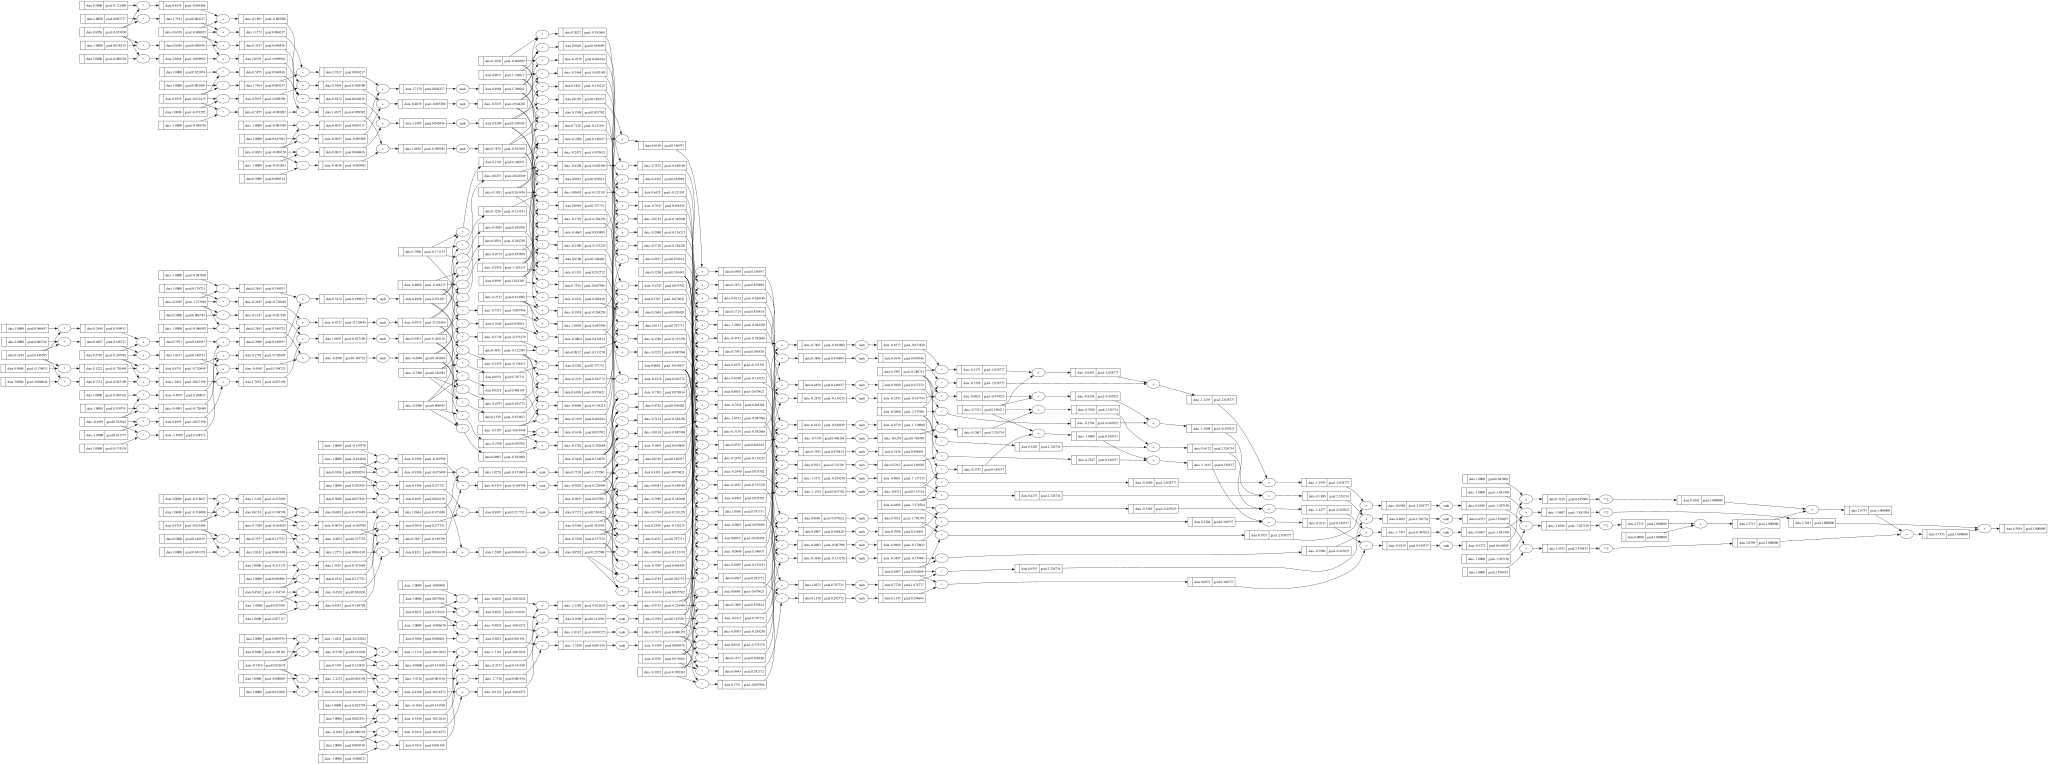

In [23]:
draw_dot(loss)

In [38]:
n.layers[0].neurons[0].w[0].grad

0.4465853210916064

In [39]:
n.layers[0].neurons[0].w[0].data

0.23543292961425438

In [40]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [42]:
n.layers[0].neurons[0].w[0].data

0.23096707640333833

In [44]:
ypred

[Value(data=-0.4804257437687598),
 Value(data=-0.6706824196899114),
 Value(data=0.26305666020602375),
 Value(data=-0.9019013645316319)]